In [28]:
#generate the route for 50 stores in Chicagoland Reuse Jug Detergent Pilot Program
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

In [29]:

# 1. Define our centers (Aurora is the Hub)
hub = {'name': 'Aurora Hub', 'lat': 41.7603, 'lon': -88.3201}
cities = {
    'Naperville': [41.7503, -88.1535],
    'Lincoln Park': [41.9214, -87.6513],
    'Evanston': [42.0451, -87.6877],
    'Oak Park': [41.8878, -87.7888],
    'Schaumburg': [42.0334, -88.0833]
}

In [30]:
# 2. Generate 50 unique store locations
stores = []
for i in range(50):
    city_name = np.random.choice(list(cities.keys()))
    base_lat, base_lon = cities[city_name]
    # Add a small random offset (~1-3 miles) so stores are unique
    lat = base_lat + np.random.uniform(-0.03, 0.03)
    lon = base_lon + np.random.uniform(-0.03, 0.03)
    stores.append({'store_id': f'STR_{i:03d}', 'city': city_name, 'lat': lat, 'lon': lon})

df_stores = pd.DataFrame(stores)
print(df_stores.head())


  store_id          city        lat        lon
0  STR_000      Evanston  42.022097 -87.717355
1  STR_001    Naperville  41.731954 -88.181593
2  STR_002    Schaumburg  42.018803 -88.105521
3  STR_003  Lincoln Park  41.938157 -87.628824
4  STR_004    Schaumburg  42.047758 -88.098224


In [31]:
# 3. Clustering: Group stores into 5 logical delivery "Routes"
# This is much more professional than simple North/South
kmeans = KMeans(n_clusters=5, n_init=10).fit(df_stores[['lat', 'lon']])
df_stores['route_id'] = kmeans.labels_

In [32]:

# 4. Calculate Distance (Simple Haversine formula)
def get_dist(lat1, lon1, lat2, lon2):
    # Rough conversion: 1 degree approx 69 miles
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2) * 69

# Calculate distance of each store from the Aurora Hub
df_stores['miles_from_hub'] = df_stores.apply(
    lambda row: get_dist(row['lat'], row['lon'], hub['lat'], hub['lon']), axis=1
)

print(f"Generated {len(df_stores)} stores across 5 optimized routes.")
print(df_stores.groupby('route_id')['miles_from_hub'].mean())

# Save to your project folder. index=False prevents an extra "Unnamed: 0" column.
import os
output_dir = '../data'

df_stores.to_csv(os.path.join(output_dir, 'stores.csv'), index=False)
print("Stores List saved!")

Generated 50 stores across 5 optimized routes.
route_id
0    11.390277
1    37.913405
2    25.003166
3    47.143531
4    47.512987
Name: miles_from_hub, dtype: float64
Stores List saved!


In [33]:
#print and summarize the routes

# Filter to see only stores assigned to a specific route
#print(df_stores[df_stores['route_id'] == 1])

# Show how many stores are in each route and their average distance from the hub
summary = df_stores.groupby('route_id').agg({
    'store_id': 'count',
    'miles_from_hub': 'mean'
}).rename(columns={'store_id': 'Number of Stores', 'miles_from_hub': 'Avg Miles from Hub'})

print(summary)


          Number of Stores  Avg Miles from Hub
route_id                                      
0                       16           11.390277
1                       10           37.913405
2                       10           25.003166
3                        7           47.143531
4                        7           47.512987


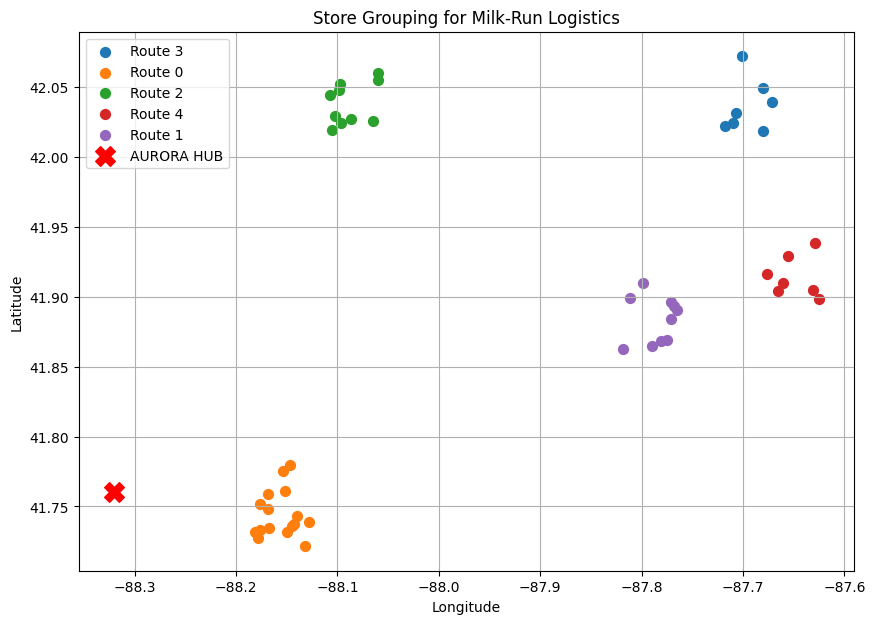

In [34]:
#plot the routes
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 7))

# Plot each cluster with a different color
for route in df_stores['route_id'].unique():
    subset = df_stores[df_stores['route_id'] == route]
    plt.scatter(subset['lon'], subset['lat'], label=f'Route {route}', s=50)

# Mark the Aurora Hub specifically
plt.scatter(-88.3201, 41.7603, color='red', marker='X', s=200, label='AURORA HUB')

plt.title('Store Grouping for Milk-Run Logistics')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()